In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("df.info)
df.head(10)

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.543130,17.0,715428.0,4.720921e+06,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.674370,7.0,699157.0,4.329832e+06,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.627590,19.0,702341.0,6.884861e+06,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.393320,11.0,700250.0,4.274774e+06,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.859410,16.0,711584.0,3.787294e+06,0.0,23012320.01,southeast,1137.0110
5,18.0,male,34.43,0.0,no,26488.339120,20.0,717162.0,3.696161e+06,0.0,NaN,southeast,1137.4697
6,18.0,male,37.29,0.0,no,33217.365480,13.0,699159.0,8.765292e+05,0.0,69060665.92,southeast,1141.4451
7,18.0,male,41.14,0.0,no,46770.585330,12.0,706423.0,4.486741e+06,0.0,97193784.44,southeast,1146.7966
8,18.0,male,43.01,0.0,no,9715.650411,17.0,NaN,9.216440e+06,0.0,58881971.93,southeast,1149.3959
9,18.0,male,53.13,0.0,no,17046.585150,19.0,704425.0,1.458972e+06,0.0,94261821.45,southeast,1163.4627


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [4]:
#EDA---->Explorartory data analysis
# first null values
#second duplicates
#third outliers
#fourth label encoding

In [5]:
df.isnull().sum()

age                                 9
sex                                 0
bmi                                 3
children                            5
smoker                              0
Claim_Amount                       14
past_consultations                  6
num_of_steps                        3
Hospital_expenditure                4
NUmber_of_past_hospitalizations     2
Anual_Salary                        6
region                              0
charges                             0
dtype: int64

In [6]:
df.isnull().sum().sum()

52

In [7]:
'''
for numerical values - replace the values with mean or median
for object data type values - replace them with mode
'''

'\nfor numerical values - replace the values with mean or median\nfor object data type values - replace them with mode\n'

In [8]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [9]:
for col in df.columns:
    if df[col].dtype=="object":
        df[col]=df[col].fillna(df[col].mode()[0])
    else:
        df[col]=df[col].fillna(df[col].mean())
        

In [10]:
df.isnull().sum()

age                                0
sex                                0
bmi                                0
children                           0
smoker                             0
Claim_Amount                       0
past_consultations                 0
num_of_steps                       0
Hospital_expenditure               0
NUmber_of_past_hospitalizations    0
Anual_Salary                       0
region                             0
charges                            0
dtype: int64

In [11]:
df.duplicated().sum()

0

In [12]:
# let supose we hade a duplicated values
# df.drop_duplicates(inplace=True)

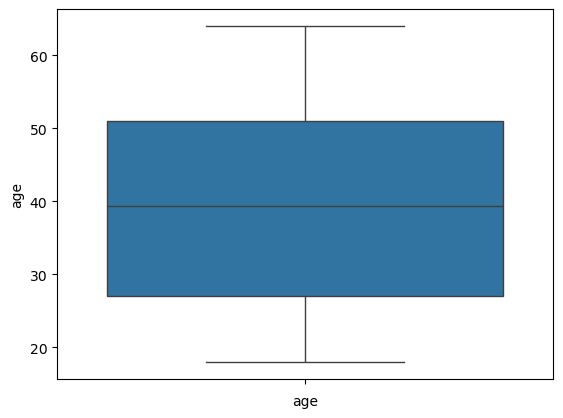

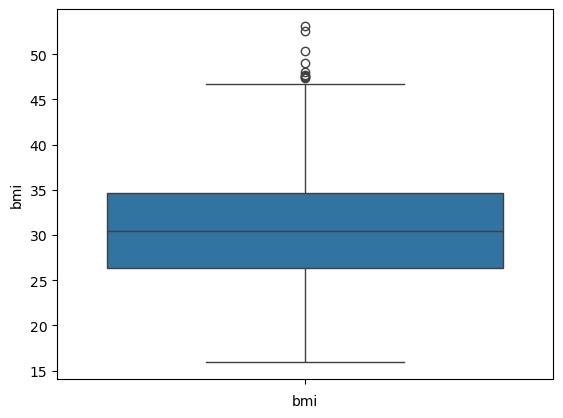

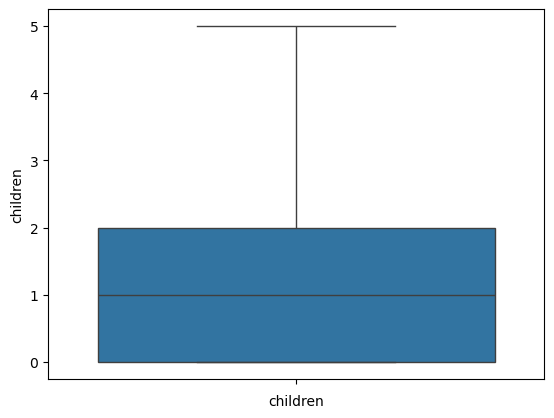

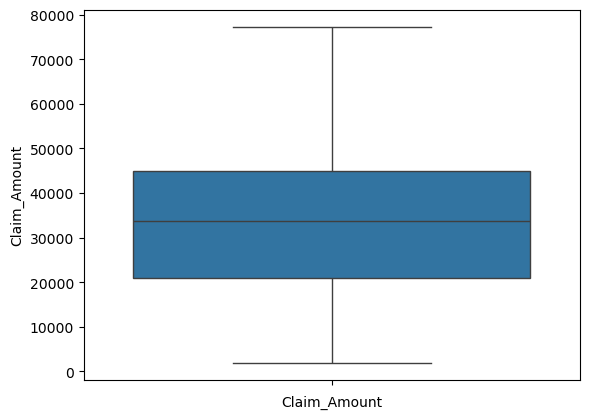

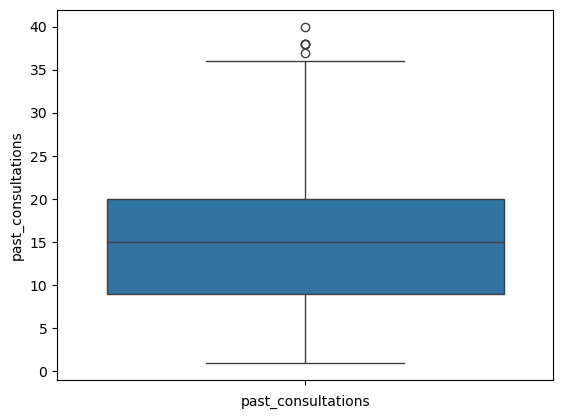

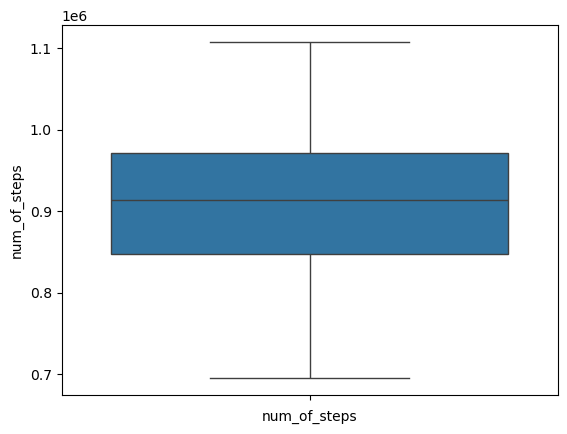

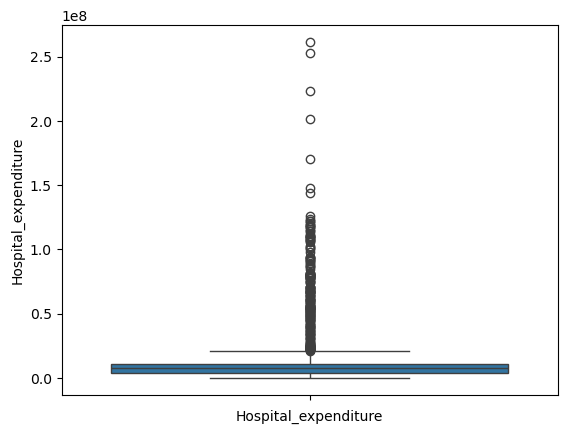

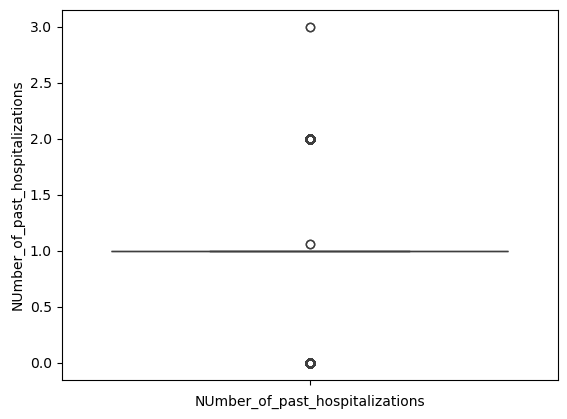

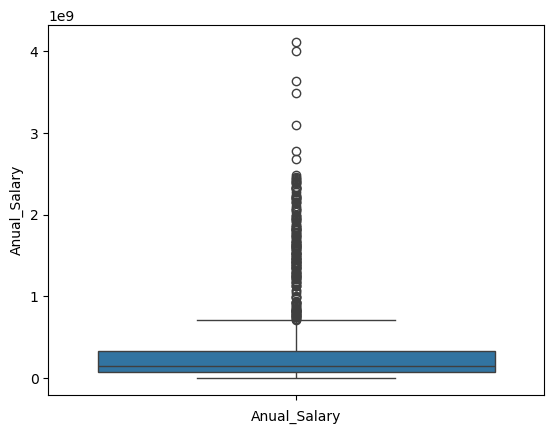

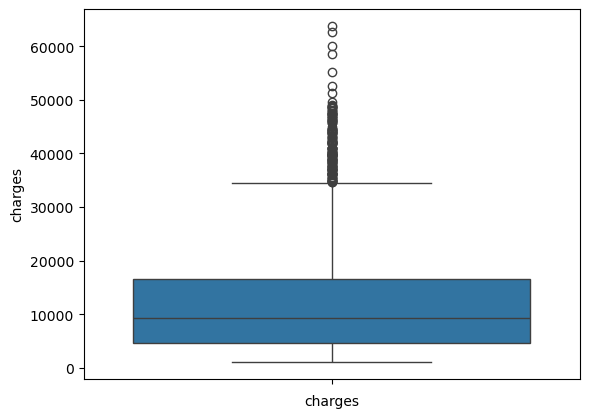

In [13]:
for col in df.columns:
    if df[col].dtype !="object":
        sns.boxplot(df[col])
        plt.xlabel(col)
        plt.show()

In [14]:
out_list = ["bmi","past_consultations","Hospital_expenditure","Anual_Salary"]
for col in out_list:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3-Q1

    LB = Q1-1.5*(IQR)
    UB = Q3+1.5*(IQR)
    df = df[(df[col]>=LB) & (df[col]<=UB)]

In [15]:
df.shape

(1030, 13)

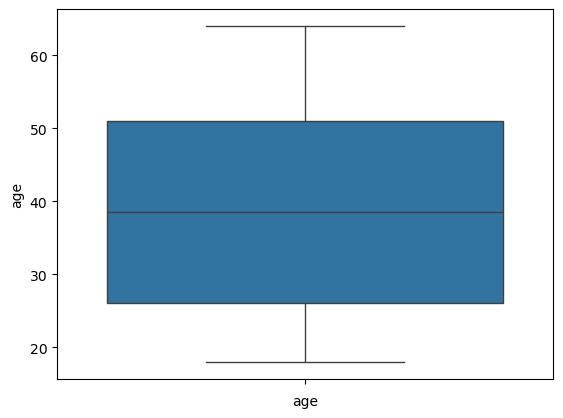

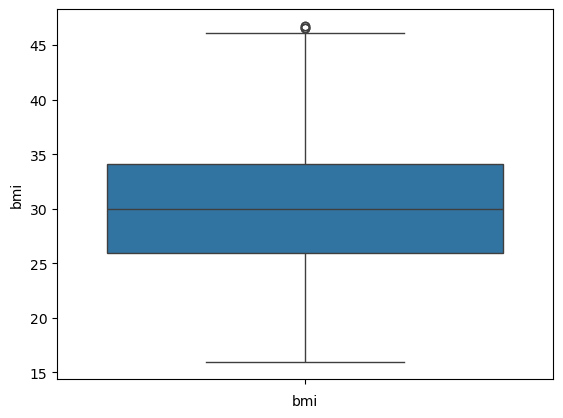

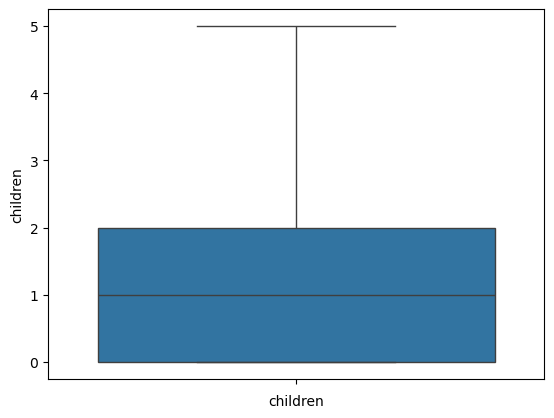

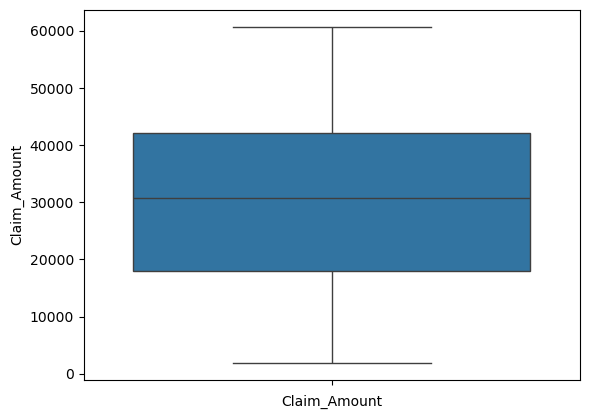

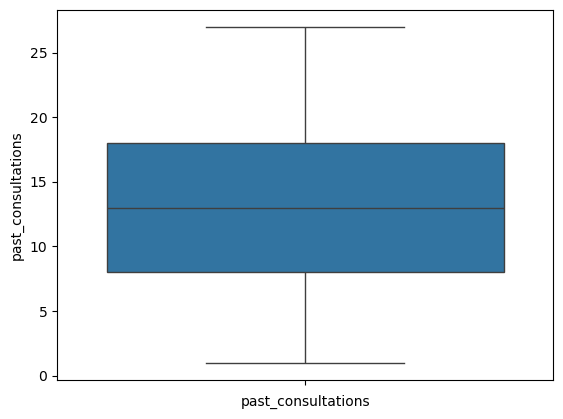

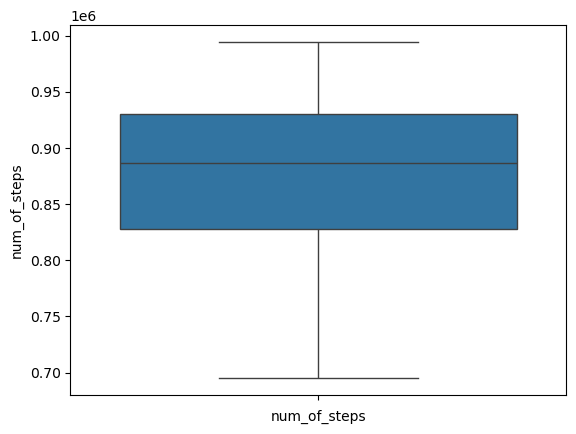

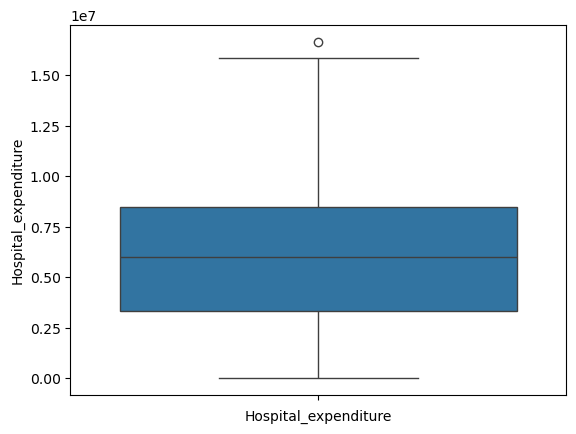

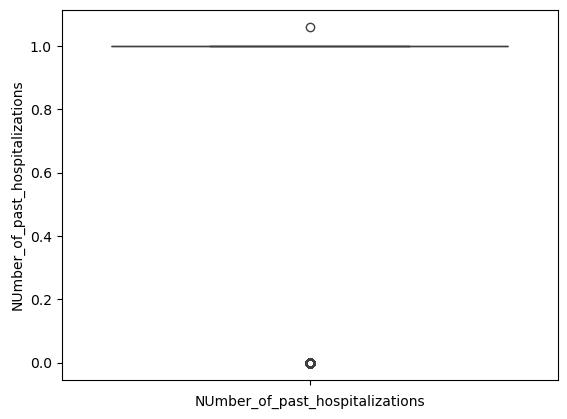

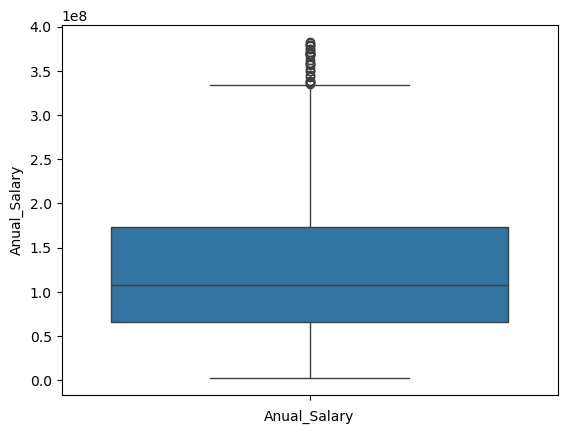

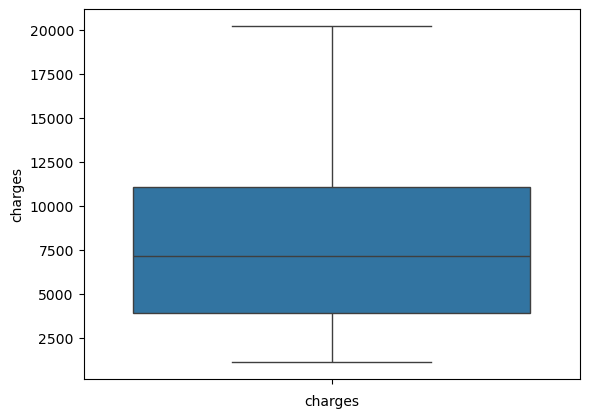

In [16]:
for col in df.columns:
    if df[col].dtype !="object":
        sns.boxplot(df[col])
        plt.xlabel(col)
        plt.show()

In [17]:
#label encoder

In [18]:
from sklearn.preprocessing import LabelEncoder

In [19]:
LE = LabelEncoder()

for col in df.columns:
    if df[col].dtype =="object":
        df[col]=LE.fit_transform(df[col])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1030 entries, 0 to 1069
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1030 non-null   float64
 1   sex                              1030 non-null   int32  
 2   bmi                              1030 non-null   float64
 3   children                         1030 non-null   float64
 4   smoker                           1030 non-null   int32  
 5   Claim_Amount                     1030 non-null   float64
 6   past_consultations               1030 non-null   float64
 7   num_of_steps                     1030 non-null   float64
 8   Hospital_expenditure             1030 non-null   float64
 9   NUmber_of_past_hospitalizations  1030 non-null   float64
 10  Anual_Salary                     1030 non-null   float64
 11  region                           1030 non-null   int32  
 12  charges                  

In [21]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2,1121.87390
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2,1131.50660
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2,1135.94070
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2,1136.39940
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1046,29.0,0,27.940,1.0,1,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,2,19107.77960
1048,31.0,1,25.900,3.0,1,46619.40230,27.0,989387.0,1.361938e+07,1.0,3.812895e+08,3,19199.94400
1050,31.0,1,29.810,0.0,1,24382.58056,21.0,973924.0,1.028991e+07,1.0,3.745310e+08,2,19350.36890
1062,43.0,0,20.045,2.0,1,21596.43846,10.0,994419.0,1.083030e+07,1.0,3.696849e+08,0,19798.05455


# model building 
**1. split the data in terms of x and y
2. split the data in trems of trainning and testing
3. initialize the model
4. train the model
5. test the model /predications
6. evaluate**

In [22]:
x = df.drop("charges",axis = 1)
y = df["charges"]

In [23]:
x

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1046,29.0,0,27.940,1.0,1,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,2
1048,31.0,1,25.900,3.0,1,46619.40230,27.0,989387.0,1.361938e+07,1.0,3.812895e+08,3
1050,31.0,1,29.810,0.0,1,24382.58056,21.0,973924.0,1.028991e+07,1.0,3.745310e+08,2
1062,43.0,0,20.045,2.0,1,21596.43846,10.0,994419.0,1.083030e+07,1.0,3.696849e+08,0


In [24]:
y

0        1121.87390
1        1131.50660
2        1135.94070
3        1136.39940
4        1137.01100
           ...     
1046    19107.77960
1048    19199.94400
1050    19350.36890
1062    19798.05455
1069    20234.85475
Name: charges, Length: 1030, dtype: float64

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.80, random_state=0)

In [27]:
x_train

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
746,55.0,1,27.645,0.0,0,25238.363470,11.0,935369.0,2.086869e+06,1.0,1.649883e+08,1
641,50.0,0,25.600,0.0,0,37222.476360,9.0,906234.0,6.062378e+06,1.0,9.657123e+07,3
999,19.0,1,26.030,1.0,1,30825.190070,11.0,953289.0,5.923489e+06,1.0,3.029514e+08,1
281,33.0,0,24.310,0.0,0,9560.754493,15.0,821360.0,3.185350e+06,1.0,7.490390e+07,2
802,52.0,0,38.380,2.0,0,12992.139950,24.0,933863.0,4.075903e+06,1.0,2.061268e+08,0
...,...,...,...,...,...,...,...,...,...,...,...,...
279,30.0,0,32.400,1.0,0,20150.675120,9.0,832253.0,1.747107e+05,1.0,6.328892e+07,3
768,57.0,1,28.100,0.0,0,9582.708574,11.0,929888.0,1.046259e+07,1.0,1.850292e+08,3
841,58.0,1,30.305,0.0,0,31405.793590,12.0,939497.0,9.380141e+06,1.0,2.118739e+08,0
561,44.0,1,37.100,2.0,0,9816.604000,12.0,897353.0,8.134594e+05,1.0,1.287152e+08,3


In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
model = LinearRegression()

In [30]:
model.fit(x_train,y_train)

LinearRegression()

In [31]:
y_pred = model.predict(x_test)
y_pred

array([10673.05379399, 10699.83913291,  2186.42137181, 12338.39922293,
       10192.54061323,  2659.12550617,  5426.76886423,  3469.69258958,
       -1236.78004776,   645.14063905, 10735.69608981,  5503.26187945,
        4188.64912169,  8913.27002696,  6628.23029543,  7463.34273736,
        5465.49165077, 11980.87478709, 10057.88642925,  4164.93396731,
        6533.03413265,  8865.63767756,  6362.50895172, 12362.32372697,
        8793.35906778,  9370.32302973,  1829.0373281 ,  2874.64700558,
        7856.29241282,  5288.7411474 ,  9778.8944672 , 11670.73244073,
        9573.2926357 ,   415.58680872, 11262.15425817,  8954.54978999,
        1968.30497405,  4441.28668083,  9834.35085472,  2171.0893951 ,
        1099.2044257 ,  9634.76758667, 11986.27375973,  5983.91725522,
        5766.43661594,  3159.18006484,  9702.42612942, 11240.08293343,
        1723.15446295,  1471.03076215, 12509.43688104, 11824.73170683,
       11101.97278486,  4156.31678115,  7673.94672659,  4857.90398477,
      

In [32]:
result =pd.DataFrame(columns=["Actual","predicted"])
result

,Actual,predicted


In [33]:
result["Actual"]=y_test
result["predicted"]=y_pred
result

,Actual,predicted
752,10704.47000,10673.053794
723,10197.77220,10699.839133
177,2801.25880,2186.421372
834,11848.14100,12338.399223
718,10107.22060,10192.540613
...,...,...
627,8688.85885,8209.580049
993,16085.12750,14735.394890
426,5976.83110,6725.909135
895,12925.88600,13030.191315


In [34]:
from sklearn.metrics import *

In [35]:
r2_score(y_test,y_pred)*100

94.75771114609961

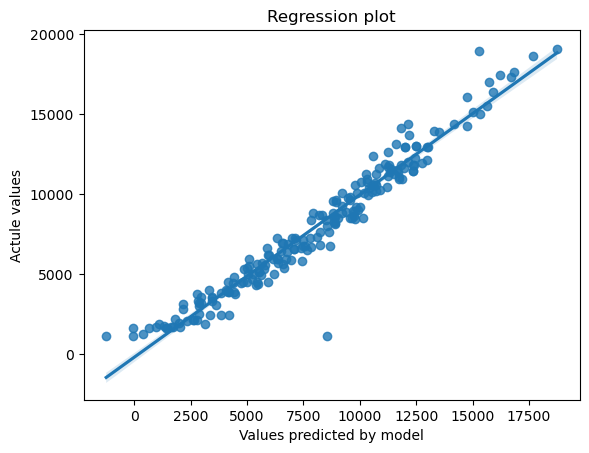

In [37]:
sns.regplot(x = y_pred, y=y_test)
plt.xlabel("Values predicted by model")
plt.ylabel("Actule values")
plt.title("Regression plot")
plt.show()

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df =pd.read_csv("new_insurance_data (1).csv")
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In [4]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [6]:
#EDA

In [7]:
df.isnull().sum()

age                                 9
sex                                 0
bmi                                 3
children                            5
smoker                              0
Claim_Amount                       14
past_consultations                  6
num_of_steps                        3
Hospital_expenditure                4
NUmber_of_past_hospitalizations     2
Anual_Salary                        6
region                              0
charges                             0
dtype: int64

In [8]:
for col in df.columns:
    if df[col].dtype =="object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col]=df[col].fillna(df[col].mean())

In [9]:
df.isnull().sum()

age                                0
sex                                0
bmi                                0
children                           0
smoker                             0
Claim_Amount                       0
past_consultations                 0
num_of_steps                       0
Hospital_expenditure               0
NUmber_of_past_hospitalizations    0
Anual_Salary                       0
region                             0
charges                            0
dtype: int64

In [10]:
df.duplicated().sum()

0

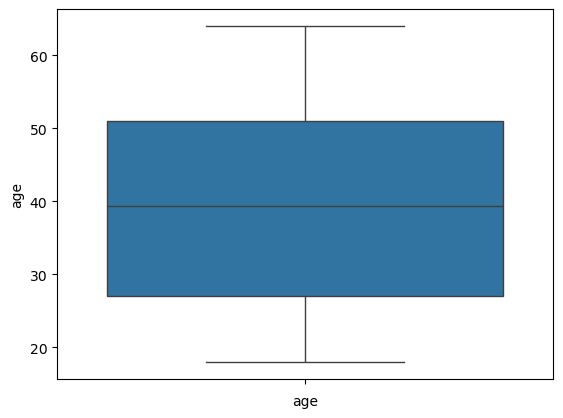

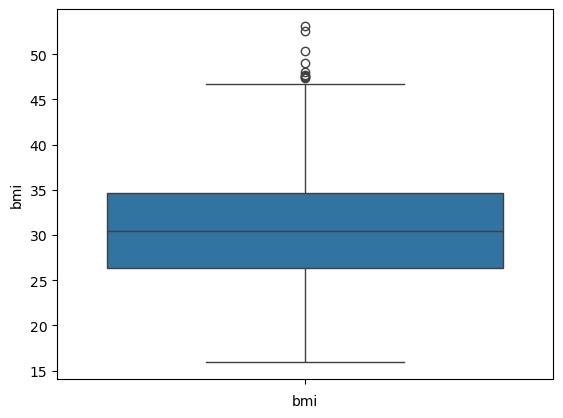

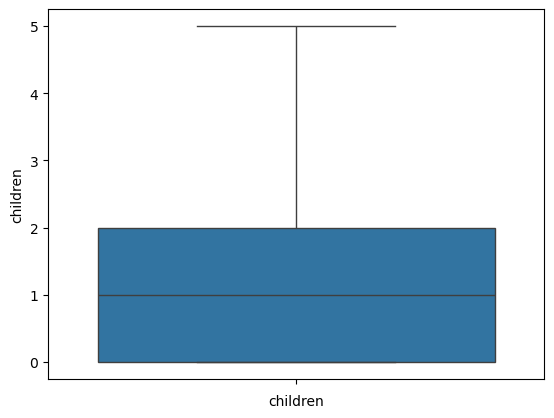

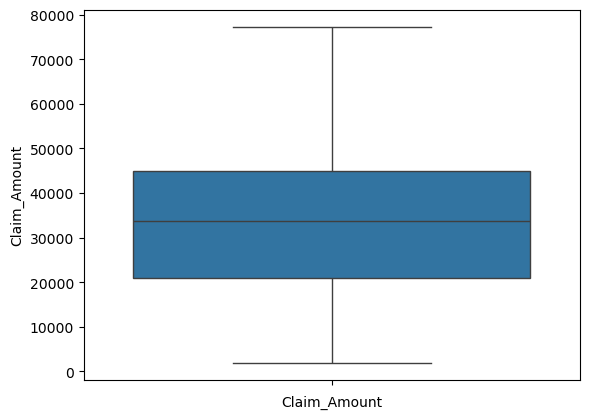

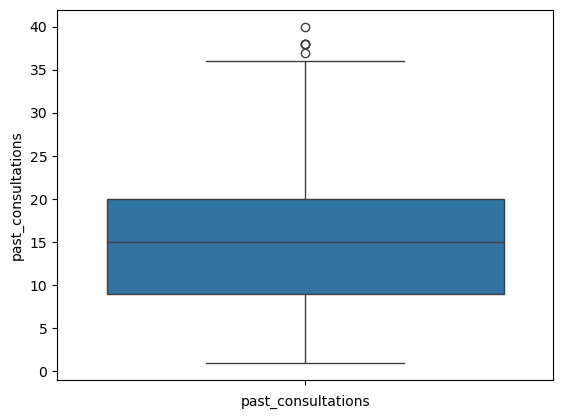

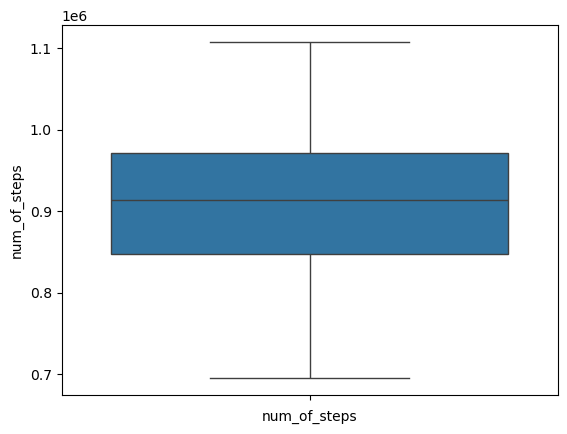

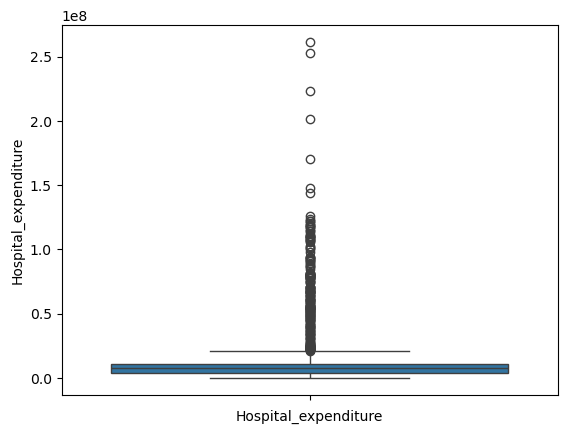

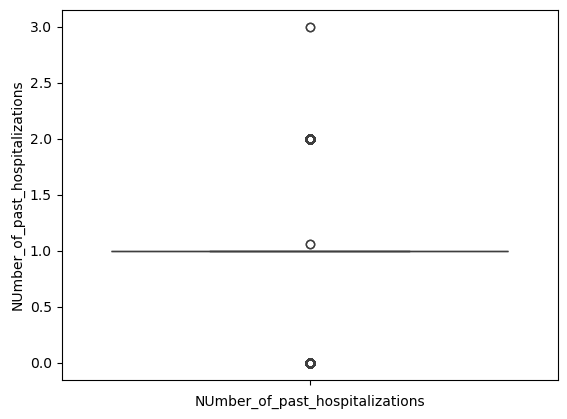

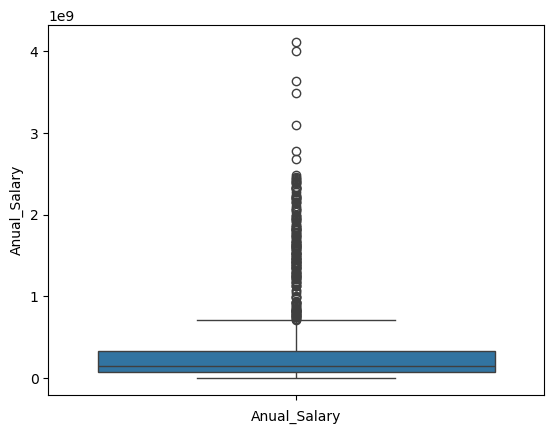

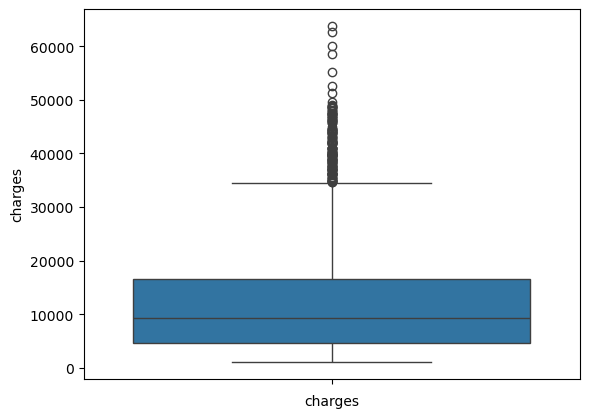

In [11]:
#check outliears
for col in df.columns:
    if df[col].dtype !="object":
        sns.boxplot(df[col])
        plt.xlabel(col)
        plt.show()

In [12]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [13]:
list = ["bmi","past_consultations", "Hospital_expenditure", "Anual_Salary"]

for i in list:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3-Q1
    LB = Q1-1.5*(IQR)
    UB = Q3+1.5*(IQR)
    df = df[(df[i]>=LB)&(df[i]<=UB)]

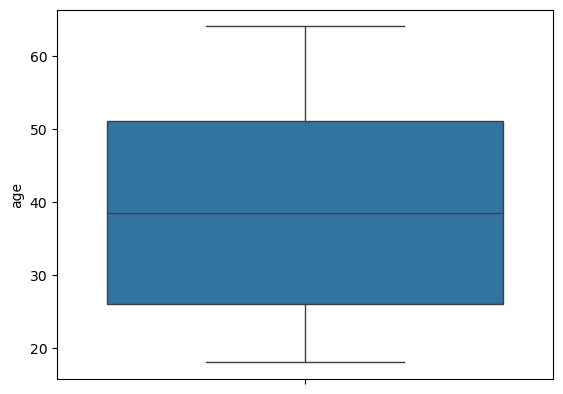

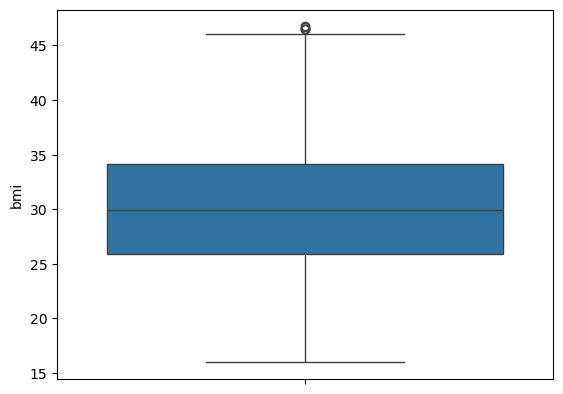

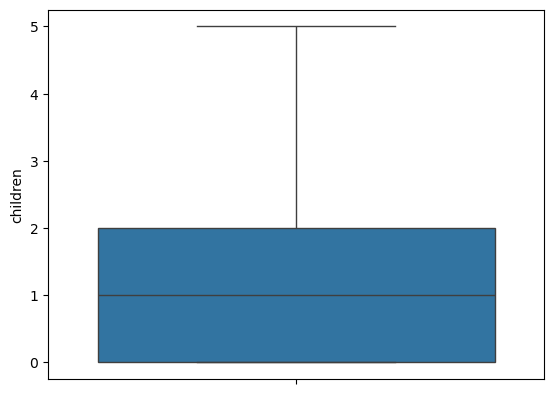

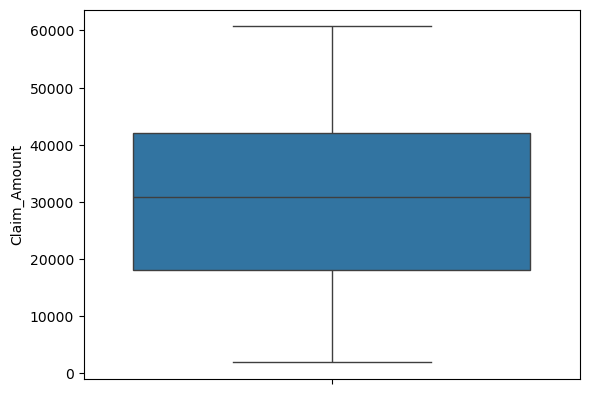

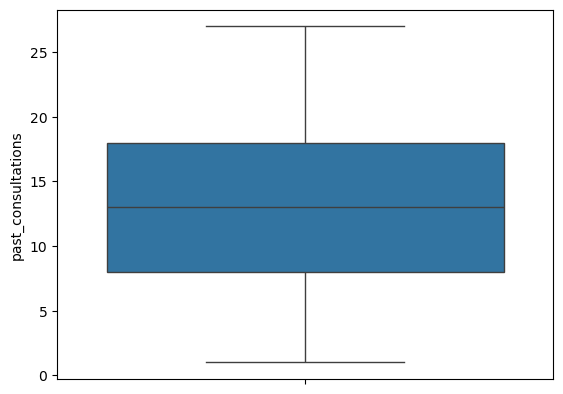

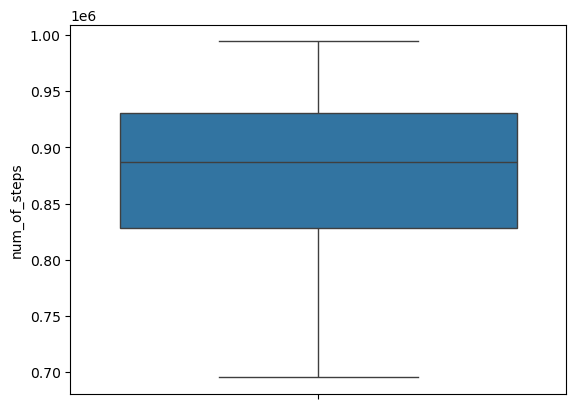

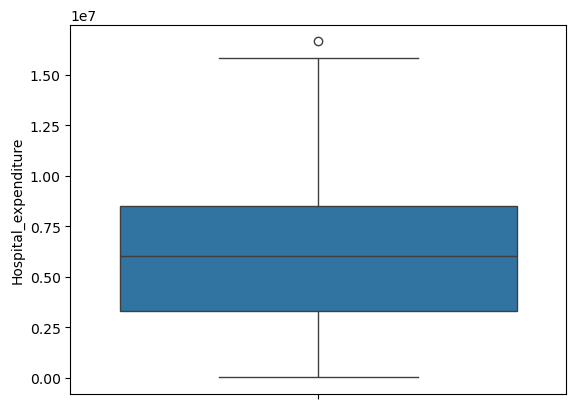

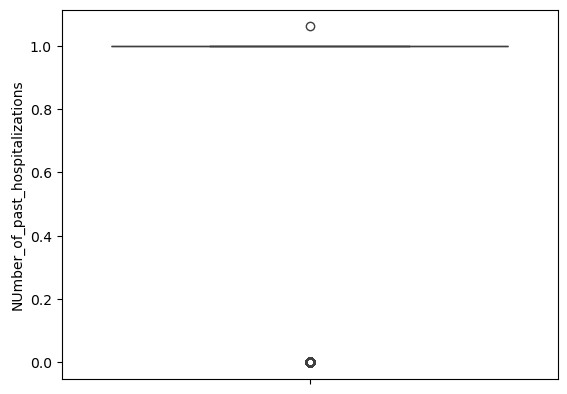

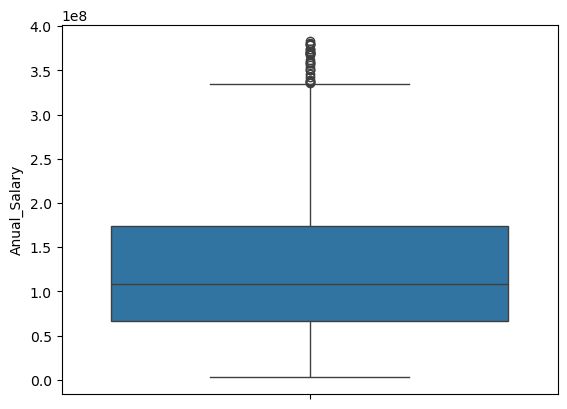

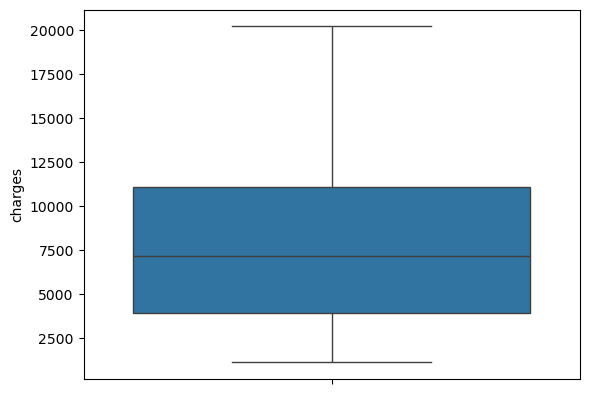

In [14]:
for col in df.columns:
    if df[col].dtype !="object":
        sns.boxplot(df[col])
        plt.show()

In [15]:
# label encoding 


In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
le = LabelEncoder()

In [18]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [19]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2,1121.87390
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2,1131.50660
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2,1135.94070
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2,1136.39940
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1046,29.0,0,27.940,1.0,1,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,2,19107.77960
1048,31.0,1,25.900,3.0,1,46619.40230,27.0,989387.0,1.361938e+07,1.0,3.812895e+08,3,19199.94400
1050,31.0,1,29.810,0.0,1,24382.58056,21.0,973924.0,1.028991e+07,1.0,3.745310e+08,2,19350.36890
1062,43.0,0,20.045,2.0,1,21596.43846,10.0,994419.0,1.083030e+07,1.0,3.696849e+08,0,19798.05455


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1030 entries, 0 to 1069
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1030 non-null   float64
 1   sex                              1030 non-null   int32  
 2   bmi                              1030 non-null   float64
 3   children                         1030 non-null   float64
 4   smoker                           1030 non-null   int32  
 5   Claim_Amount                     1030 non-null   float64
 6   past_consultations               1030 non-null   float64
 7   num_of_steps                     1030 non-null   float64
 8   Hospital_expenditure             1030 non-null   float64
 9   NUmber_of_past_hospitalizations  1030 non-null   float64
 10  Anual_Salary                     1030 non-null   float64
 11  region                           1030 non-null   int32  
 12  charges                  

In [21]:
#model building part

In [22]:
x = df.drop("charges", axis = 1)
y = df["charges"]

In [23]:
x

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1046,29.0,0,27.940,1.0,1,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,2
1048,31.0,1,25.900,3.0,1,46619.40230,27.0,989387.0,1.361938e+07,1.0,3.812895e+08,3
1050,31.0,1,29.810,0.0,1,24382.58056,21.0,973924.0,1.028991e+07,1.0,3.745310e+08,2
1062,43.0,0,20.045,2.0,1,21596.43846,10.0,994419.0,1.083030e+07,1.0,3.696849e+08,0


In [24]:
y

0        1121.87390
1        1131.50660
2        1135.94070
3        1136.39940
4        1137.01100
           ...     
1046    19107.77960
1048    19199.94400
1050    19350.36890
1062    19798.05455
1069    20234.85475
Name: charges, Length: 1030, dtype: float64

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
tts = train_test_split
x_train,x_test,y_train,y_test = tts(x,y,train_size = 0.80, random_state=0)
x_train

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
746,55.0,1,27.645,0.0,0,25238.363470,11.0,935369.0,2.086869e+06,1.0,1.649883e+08,1
641,50.0,0,25.600,0.0,0,37222.476360,9.0,906234.0,6.062378e+06,1.0,9.657123e+07,3
999,19.0,1,26.030,1.0,1,30825.190070,11.0,953289.0,5.923489e+06,1.0,3.029514e+08,1
281,33.0,0,24.310,0.0,0,9560.754493,15.0,821360.0,3.185350e+06,1.0,7.490390e+07,2
802,52.0,0,38.380,2.0,0,12992.139950,24.0,933863.0,4.075903e+06,1.0,2.061268e+08,0
...,...,...,...,...,...,...,...,...,...,...,...,...
279,30.0,0,32.400,1.0,0,20150.675120,9.0,832253.0,1.747107e+05,1.0,6.328892e+07,3
768,57.0,1,28.100,0.0,0,9582.708574,11.0,929888.0,1.046259e+07,1.0,1.850292e+08,3
841,58.0,1,30.305,0.0,0,31405.793590,12.0,939497.0,9.380141e+06,1.0,2.118739e+08,0
561,44.0,1,37.100,2.0,0,9816.604000,12.0,897353.0,8.134594e+05,1.0,1.287152e+08,3


In [27]:
from sklearn.linear_model import LinearRegression

In [29]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [30]:
y_pred = model.predict(x_test)
y_pred

array([10673.05379399, 10699.83913291,  2186.42137181, 12338.39922293,
       10192.54061323,  2659.12550617,  5426.76886423,  3469.69258958,
       -1236.78004776,   645.14063905, 10735.69608981,  5503.26187945,
        4188.64912169,  8913.27002696,  6628.23029543,  7463.34273736,
        5465.49165077, 11980.87478709, 10057.88642925,  4164.93396731,
        6533.03413265,  8865.63767756,  6362.50895172, 12362.32372697,
        8793.35906778,  9370.32302973,  1829.0373281 ,  2874.64700558,
        7856.29241282,  5288.7411474 ,  9778.8944672 , 11670.73244073,
        9573.2926357 ,   415.58680872, 11262.15425817,  8954.54978999,
        1968.30497405,  4441.28668083,  9834.35085472,  2171.0893951 ,
        1099.2044257 ,  9634.76758667, 11986.27375973,  5983.91725522,
        5766.43661594,  3159.18006484,  9702.42612942, 11240.08293343,
        1723.15446295,  1471.03076215, 12509.43688104, 11824.73170683,
       11101.97278486,  4156.31678115,  7673.94672659,  4857.90398477,
      

In [33]:
result = pd.DataFrame(columns = ["Acctual","predicated"])
result

,Acctual,predicated


In [34]:
result["Acctual"]=y_test
result["predicated"] = y_pred
result

,Acctual,predicated
752,10704.47000,10673.053794
723,10197.77220,10699.839133
177,2801.25880,2186.421372
834,11848.14100,12338.399223
718,10107.22060,10192.540613
...,...,...
627,8688.85885,8209.580049
993,16085.12750,14735.394890
426,5976.83110,6725.909135
895,12925.88600,13030.191315


In [35]:
from sklearn.metrics import *

In [37]:
r2_score(y_pred,y_test)*100

94.29335210001312

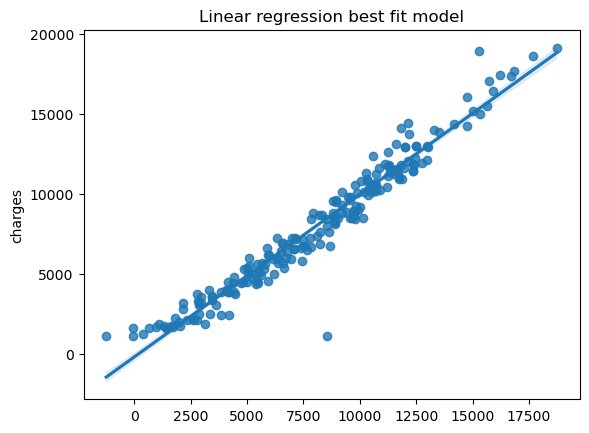

In [39]:
sns.regplot(x = y_pred,y = y_test)
plt.title("Linear regression best fit model")
plt.show()